In [1]:
!pip install optuna
import optuna
from time import time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor

from sklearn.gaussian_process.kernels import RBF, Matern, DotProduct, WhiteKernel

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("winequality-red.csv")
df.head()

Saving winequality-red.csv to winequality-red (1).csv


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Check shapes
print("Train data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Train data shape: (1119, 11)
Test data shape: (480, 11)


In [4]:
def create_model(trial):
    model_type = trial.suggest_categorical('model_type',['Logistic-regression', 'SVM'])

    if model_type == 'SVM':
        kernel = trial.suggest_categorical('SVM-kernel',['linear','poly','rbf','sigmoid'])
        C = trial.suggest_float('SVM-C',0.1, 1000,log=True)
        gamma = trial.suggest_float('SVM-gamma',0.0001, 10,log=True)
        model = SVC(kernel=kernel,C=C,gamma=gamma)

    if model_type == 'Logistic-regression':
        penalty = trial.suggest_categorical('penalty',['l1','l2'])
        if penalty == 'l1':
            solver = 'saga'
        else:
            solver = 'lbfgs'
        regularization = trial.suggest_float('Logistic-regularization',0.01, 100,log=True)
        model = LogisticRegression(penalty=penalty,C=regularization,solver=solver,max_iter=5000)

    if trial.should_prune():
        raise optuna.TrialPruned()

    return model

In [5]:
def objective(trial):
    model = create_model(trial)
    scores = cross_val_score(model,X_train,y_train,cv=5,scoring="accuracy")
    return np.mean(scores)

In [6]:
start = time()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params = study.best_params

print("\nBest parameters:", best_params)

[I 2026-03-06 11:16:57,023] A new study created in memory with name: no-name-6dbf1e6f-7649-4cb0-ab61-d7d895036710
[I 2026-03-06 11:16:57,148] Trial 0 finished with value: 0.5898302370275463 and parameters: {'model_type': 'Logistic-regression', 'penalty': 'l2', 'Logistic-regularization': 0.07849388784852773}. Best is trial 0 with value: 0.5898302370275463.
[I 2026-03-06 11:16:57,556] Trial 1 finished with value: 0.5871676809737348 and parameters: {'model_type': 'SVM', 'SVM-kernel': 'rbf', 'SVM-C': 171.20962127093026, 'SVM-gamma': 0.0011319504600606474}. Best is trial 0 with value: 0.5898302370275463.
[I 2026-03-06 11:16:57,756] Trial 2 finished with value: 0.4262732222934017 and parameters: {'model_type': 'SVM', 'SVM-kernel': 'poly', 'SVM-C': 2.2799365159729432, 'SVM-gamma': 0.001005666040083268}. Best is trial 0 with value: 0.5898302370275463.
[I 2026-03-06 11:16:58,537] Trial 3 finished with value: 0.5942865150544523 and parameters: {'model_type': 'SVM', 'SVM-kernel': 'rbf', 'SVM-C': 


Best parameters: {'model_type': 'SVM', 'SVM-kernel': 'rbf', 'SVM-C': 1.2621277876554782, 'SVM-gamma': 0.4768862861372544}


In [7]:
best_model = create_model(study.best_trial)
best_model.fit(X_train, y_train)
scores = cross_val_score(best_model, X_train, y_train, cv=5)

print("Best CV accuracy:", np.mean(scores))

y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print("Test Accuracy:", acc)
print("Test F1-score:", f1)

Best CV accuracy: 0.6166399743754004
Test Accuracy: 0.64375
Test F1-score: 0.6239696088745069


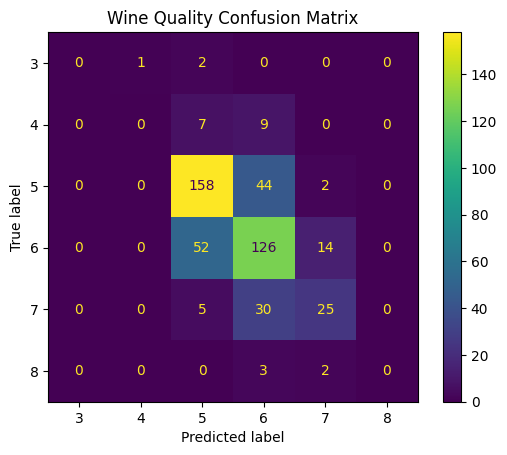

In [8]:
labels = np.unique(y)

cfm = confusion_matrix(y_test, y_pred, labels=labels)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cfm,display_labels=labels)
cm_display.plot()
plt.title("Wine Quality Confusion Matrix")
plt.show()

In [9]:
#for letter b
def create_model(trial):
    model_type = trial.suggest_categorical('model_type',['SVR', 'KRR', 'GPR'])
    if model_type == 'SVR':
        kernel = trial.suggest_categorical('SVR-kernel',['linear','poly','rbf','sigmoid'])
        C = trial.suggest_float('SVR-C',0.1, 100,log=True)
        gamma = trial.suggest_float('SVR-gamma',0.0001, 10,log=True)
        epsilon = trial.suggest_float('SVR-epsilon',0.001, 1,log=True)
        model = SVR(kernel=kernel,C=C,gamma=gamma,epsilon=epsilon)

    if model_type == 'KRR':
        alpha = trial.suggest_float('KRR-alpha',0.001, 10,log=True)
        kernel = trial.suggest_categorical('KRR-kernel',['linear','poly','rbf'])
        model = KernelRidge(alpha=alpha,kernel=kernel)

    if model_type == 'GPR':
        alpha = trial.suggest_float('GPR-alpha',1e-5, 1,log=True)
        kernel_type = trial.suggest_categorical('GPR-kernel',['rbf','matern','dot'])
        if kernel_type == 'rbf':
            kernel = RBF()
        if kernel_type == 'matern':
            kernel = Matern()
        if kernel_type == 'dot':
            kernel = DotProduct()
        kernel = kernel + WhiteKernel()
        model = GaussianProcessRegressor(kernel=kernel,alpha=alpha)

    if trial.should_prune():
        raise optuna.TrialPruned()

    return model

In [10]:
def objective(trial):
    model = create_model(trial)
    scores = cross_val_score(model,X_train,y_train,cv=5,scoring='neg_mean_squared_error')
    return np.mean(scores)

In [11]:
start = time()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)
best_params = study.best_params

print("\nBest parameters:", best_params)

[I 2026-03-06 11:19:06,283] A new study created in memory with name: no-name-b4c988c4-14d7-453a-8f70-afb612202801
[I 2026-03-06 11:19:06,939] Trial 0 finished with value: -0.7830409142957263 and parameters: {'model_type': 'KRR', 'KRR-alpha': 0.0969687354119444, 'KRR-kernel': 'poly'}. Best is trial 0 with value: -0.7830409142957263.
[I 2026-03-06 11:19:07,482] Trial 1 finished with value: -2.1387154723262536 and parameters: {'model_type': 'KRR', 'KRR-alpha': 0.0044312349929792934, 'KRR-kernel': 'poly'}. Best is trial 0 with value: -0.7830409142957263.
[I 2026-03-06 11:19:43,034] Trial 2 finished with value: -0.43679537853481526 and parameters: {'model_type': 'GPR', 'GPR-alpha': 0.2585271620847368, 'GPR-kernel': 'dot'}. Best is trial 2 with value: -0.43679537853481526.
[I 2026-03-06 11:19:43,907] Trial 3 finished with value: -1.1155877954407818 and parameters: {'model_type': 'KRR', 'KRR-alpha': 0.02169537707519019, 'KRR-kernel': 'poly'}. Best is trial 2 with value: -0.43679537853481526.



Best parameters: {'model_type': 'GPR', 'GPR-alpha': 0.3546547773897675, 'GPR-kernel': 'matern'}


In [13]:
best_model = create_model(study.best_trial)
best_model.fit(X_train, y_train)
scores = cross_val_score(best_model,X_train,y_train,cv=5,scoring='neg_mean_squared_error')
print("Best CV MSE:", -np.mean(scores))

Best CV MSE: 0.41392733185301755


In [14]:
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mad = mean_absolute_error(y_test, y_pred)

print("Test MSE:", mse)
print("Test R2:", r2)
print("Test MAD:", mad)

Test MSE: 0.37463326979627537
Test R2: 0.4221556126456112
Test MAD: 0.4683005222256078


No, the model did not improve upon the results reported in the paper. The best model in the paper achieved a MAD of approximately 0.46 for the red wine dataset, while the best model obtained in this experiment produced a MAD of 0.4683. Although the performance is very close, the error is slightly higher.

If treated as classification which predicted discrete values for quality of wine, the model achieved a test accuracy of 61.66%
F1 score of (0.623). If treated as regression, it will predict continouos value for wine quality which can allow more precise estimates. My values were MSE = 0.3746 and MAD = 0.4683, suggesting that the predicted wine quality by the model is less than a half point away from actual wine rating.

In general classification is easier if we need to label things to categories, while regression allows to look into small differences in values, which can be better for detailed analysis.